# Phase 9 - Community structure on social graphs

The professor's question: does a social graph's **natural community structure** explain when augmentation works?

Louvain community detection on **15 social graphs** - the 10 smallest by nodes (pilot) plus 5 more, marked *new* - on the original graph and on its three role graphs (`psi`, `degree`, `centrality`, K=10). The link-prediction results are the existing ones: nothing retrained, no rule changed.

**Community strength** = Louvain modularity Q: 0 = no communities, 1 = very strong communities.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from virgo import config as cfg
from virgo import frozen_rules as fr

# Same table style as notebooks 6-7: fixed layout + wrapped headers, so a wide table never scrolls out of the output area.
STYLE = [
    {"selector": "table", "props": [("width", "100%"), ("table-layout", "fixed"), ("font-size", "11px")]},
    {"selector": "th", "props": [("white-space", "normal"), ("word-wrap", "break-word"), ("text-align", "center"), ("padding", "4px")]},
    {"selector": "td", "props": [("white-space", "normal"), ("word-wrap", "break-word"), ("text-align", "center"), ("padding", "4px")]},
]
show = lambda df, digits=2: display(df.style.format(precision=digits).set_table_styles(STYLE).hide(axis="index"))
signals = lambda s: s.str.replace("|", " / ", regex=False)

PANEL = cfg.COMMUNITY_SOCIAL                     # the locked pool: pilot 10 + 5 added
NEW = set(cfg.COMMUNITY_SOCIAL_ADDED)
mark = lambda n: f"{n} (new)" if n in NEW else n
cmp = pd.read_csv("results/community_compare.csv").set_index("dataset").loc[PANEL].reset_index()
summary = pd.read_csv("results/community_summary.csv")
summary = summary[summary.dataset.isin(PANEL)]
corr10 = pd.read_csv("results/community_correlations.csv")       # pilot, 10 graphs - kept as it was
corr = pd.read_csv("results/community_correlations_15.csv")      # final pool, 15 graphs
graphs = pd.read_csv("results/community_graphs.csv")
graphs = graphs[graphs.dataset.isin(PANEL)]
rho = lambda x, y, c=corr: c[(c.x == x) & (c.y == y)].value.iloc[0]
named = lambda d: d.assign(dataset=d.dataset.map(mark))          # graph names with the (new) marker, for plot labels

# Chart tokens: light surface, solid hairline grid, ink-coloured text; two colour-blind-safe categorical slots.
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VERDICT = {"augment": BLUE, "keep original": ORANGE}
SEQ = LinearSegmentedColormap.from_list("blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
                     "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
                     "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
                     "grid.linestyle": "-", "axes.axisbelow": True, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
                     "figure.dpi": 100})


def dots(ax, d, x, y, colour_by):
    '''One dot per graph, coloured by keep / augment, with a surface ring so overlapping dots stay legible.'''
    for level, colour in VERDICT.items():
        s = d[d[colour_by] == level]
        ax.scatter(s[x], s[y], s=60, color=colour, edgecolor=SURFACE, linewidth=1.5, zorder=3, label=level)


def label_points(ax, d, x, y, gap=1.5):
    '''Graph names beside the dots, repelled vertically until no two labels (or a label and the legend) overlap;
    a label pushed away from its dot keeps a thin leader line. Call after tight_layout() and legend().'''
    r = ax.figure.canvas.get_renderer()
    box = ax.bbox
    leg = ax.get_legend().get_window_extent(r) if ax.get_legend() else None
    dots = [tuple(ax.transData.transform((a, b))) for a, b in zip(d[x], d[y])]
    on_dot = lambda x0, y0, w, h, own: [(ox, oy) for ox, oy in dots if (ox, oy) != own
                                        and x0 - 5 < ox < x0 + w + 5 and y0 - 5 < oy < y0 + h + 5]
    items = []
    for a, b, name in zip(d[x], d[y], d["dataset"]):
        px, py = ax.transData.transform((a, b))
        t = ax.text(0, 0, name, fontsize=7.5)
        bb = t.get_window_extent(r)
        t.remove()
        w, h = bb.width, bb.height
        fits_r, fits_l = px + 6 + w <= box.x1 - 2, px - 6 - w >= box.x0 + 2
        # the side of the dot whose label would cover fewer other dots (right on a tie)
        right = fits_r and (not fits_l or len(on_dot(px + 6, py + 2, w, h, (px, py))) <= len(on_dot(px - 6 - w, py + 2, w, h, (px, py))))
        items.append({"name": name, "xy": (a, b), "px": px, "py": py, "right": right, "w": w, "h": h,
                      "x0": px + 6 if right else px - 6 - w, "y0": py + 2})
    hit = lambda A, B: A["x0"] < B["x0"] + B["w"] and B["x0"] < A["x0"] + A["w"]
    for _ in range(400):
        moved = False
        items.sort(key=lambda i: i["y0"])
        for i, A in enumerate(items):
            for B in items[i + 1:]:
                over = A["y0"] + A["h"] + gap - B["y0"]
                if over > 0 and hit(A, B):
                    A["y0"] -= over / 2
                    B["y0"] += over / 2
                    moved = True
            for ox, oy in on_dot(A["x0"], A["y0"], A["w"], A["h"], (A["px"], A["py"])):
                A["y0"] = oy + 5 if A["y0"] + A["h"] / 2 >= oy else oy - 5 - A["h"]   # step off another graph's dot
                moved = True
            if leg is not None and A["x0"] < leg.x1 and leg.x0 < A["x0"] + A["w"] and A["y0"] < leg.y1 and leg.y0 < A["y0"] + A["h"]:
                A["y0"] = leg.y0 - A["h"] - gap                       # never under the legend
                moved = True
            A["y0"] = min(max(A["y0"], box.y0 + 1), box.y1 - A["h"] - 1)
        if not moved:
            break
    for it in items:
        dx = it["x0"] - it["px"] if it["right"] else it["x0"] + it["w"] - it["px"]
        dy = it["y0"] - it["py"]
        far = abs(dy - 2) > 4
        ax.annotate(it["name"], it["xy"], xytext=(dx, dy), textcoords="offset pixels",
                    ha="left" if it["right"] else "right", va="bottom", fontsize=7.5, color=INK2,
                    arrowprops=dict(arrowstyle="-", color=AXIS, linewidth=0.6, shrinkA=0, shrinkB=3) if far else None)


def heatmap(ax, mat, title):
    '''Graphs x columns, one sequential hue (0 = light, 1 = dark), each value printed in ink or white.'''
    ax.imshow(mat.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(mat.shape[1]), mat.columns)
    ax.set_yticks(range(mat.shape[0]), mat.index)
    ax.grid(False)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.55 else INK)
    ax.set_title(title)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)


print(f"graphs ({len(PANEL)}): pilot {cfg.COMMUNITY_SOCIAL_PILOT} + new {cfg.COMMUNITY_SOCIAL_ADDED}")
print("Louvain: resolution 1, seeds 42-44 (averaged) | link prediction: existing GraphSAGE results, K=10")

graphs (15): pilot ['spanish_highschool_6', 'reed98', 'twitch_ptbr', 'amherst41', 'twitch_ru', 'twitch_es', 'johnshopkins55', 'blogcatalog', 'twitch_fr', 'twitch_engb'] + new ['flickr_attr', 'lastfm_asia', 'twitch_de', 'cornell5', 'deezer_europe']
Louvain: resolution 1, seeds 42-44 (averaged) | link prediction: existing GraphSAGE results, K=10


## 1 · The answers

The professor's three questions, and what the 15 graphs show (pilot-10 values in brackets). **Keep** = the original graph beats the pure role graphs. Each one is detailed in §3-§5.

In [2]:
aug, keep = cmp[cmp.nonhybrid_verdict == "augment"], cmp[cmp.nonhybrid_verdict == "keep original"]
lowh = cmp[cmp.stage1_call == "augment"]                     # rule 1 fired = low homophily (all social graphs are low-clustering)
weak = lowh[lowh.orig_modularity < 0.5]
role_hub = aug[["hub_cross_psi", "hub_cross_degree", "hub_cross_centrality"]]
chance = summary[(summary.variant == "original") & summary.dataset.isin(aug.dataset)].chance_cross
lower = (aug.hub_cross_centrality < aug[["hub_cross_psi", "hub_cross_degree"]].min(axis=1)).sum()
grp = corr[(corr.statistic != "spearman") & (corr.y == "nonhybrid_verdict")].iloc[0]
show(pd.DataFrame([
    {"professor's question": "Low homophily + low clustering = weak communities, where augmentation helps?",
     "answer": "Partly",
     "what we found": f"Low homophily: mostly - {len(weak)} of the {len(lowh)} low-homophily graphs have weak communities "
                      f"(Q {weak.orig_modularity.min():.2f}-{weak.orig_modularity.max():.2f}), and augmentation helps on "
                      f"{int((weak.nonhybrid_verdict == 'augment').sum())} of these {len(weak)}; "
                      f"the exception, {', '.join(lowh[lowh.orig_modularity >= 0.5].dataset)}, has strong communities and is a keep case. "
                      f"Low clustering: no - ρ(Q, clustering) {rho('orig_modularity', 'avg_clustering'):+.2f} "
                      f"[{rho('orig_modularity', 'avg_clustering', corr10):+.2f}]."},
    {"professor's question": "Strong communities (or high clustering) = keep the original graph?",
     "answer": "Yes for communities; no for clustering",
     "what we found": f"The {len(keep)} keep graphs have the {len(keep)} strongest communities "
                      f"(Q {keep.orig_modularity.min():.2f}-{keep.orig_modularity.max():.2f}); every augment graph is ≤ "
                      f"{aug.orig_modularity.max():.2f}. Weaker communities, bigger gain: ρ {rho('orig_modularity', 'nonhybrid_gap'):+.2f} "
                      f"[{rho('orig_modularity', 'nonhybrid_gap', corr10):+.2f}]; keep vs augment p {grp.p:.3f}."},
    {"professor's question": "When augmentation helps, is centrality useful because it links important nodes across (or within) communities?",
     "answer": "No",
     "what we found": f"Role edges ignore communities: {role_hub.min().min():.0%}-{role_hub.max().max():.0%} of hub edges cross "
                      f"them, close to random ({chance.min():.0%}-{chance.max():.0%}). Centrality stays inside communities a bit "
                      f"more ({lower} of {len(aug)} graphs) - where it wins and where it loses alike "
                      f"(ρ {rho('hub_cross_centrality', 'centrality_advantage'):+.2f} [{rho('hub_cross_centrality', 'centrality_advantage', corr10):+.2f}])."},
]))

professor's question,answer,what we found
"Low homophily + low clustering = weak communities, where augmentation helps?",Partly,"Low homophily: mostly - 11 of the 12 low-homophily graphs have weak communities (Q 0.24-0.47), and augmentation helps on 11 of these 11; the exception, deezer_europe, has strong communities and is a keep case. Low clustering: no - ρ(Q, clustering) -0.20 [-0.03]."
Strong communities (or high clustering) = keep the original graph?,Yes for communities; no for clustering,"The 3 keep graphs have the 3 strongest communities (Q 0.68-0.81); every augment graph is ≤ 0.47. Weaker communities, bigger gain: ρ -0.83 [-0.54]; keep vs augment p 0.004."
"When augmentation helps, is centrality useful because it links important nodes across (or within) communities?",No,"Role edges ignore communities: 63%-87% of hub edges cross them, close to random (74%-90%). Centrality stays inside communities a bit more (11 of 12 graphs) - where it wins and where it loses alike (ρ -0.33 [-0.26])."


## 2 · Community detection, per graph

Louvain on the **original** graph, next to the stage-1 call and the existing link-prediction results: original vs the pure role graphs, and the official verdict over all 7 variants (hybrids included).

graph,set,nodes,edges,communities found,community strength (Q),stage 1 says,original vs role graphs,official (7 variants),winning signal
spanish_highschool_6,pilot,534,9527,4,0.71,keep original,keep original,keep original,original
reed98,pilot,962,18812,6,0.32,augment,augment,augment,centrality
twitch_ptbr,pilot,1912,31299,8,0.29,augment,augment,augment,degree / psi
amherst41,pilot,2235,90954,6,0.44,augment,augment,augment,centrality / degree / psi
twitch_ru,pilot,4385,37304,11,0.34,augment,augment,augment,degree / psi
twitch_es,pilot,4648,59382,10,0.40,augment,augment,augment,degree / psi
johnshopkins55,pilot,5180,186586,19,0.45,augment,augment,augment,centrality
blogcatalog,pilot,5196,171743,9,0.37,keep original,augment,augment,centrality / degree / psi
twitch_fr,pilot,6549,112666,8,0.34,augment,augment,augment,degree / psi
twitch_engb,pilot,7126,35324,20,0.45,augment,augment,augment,degree


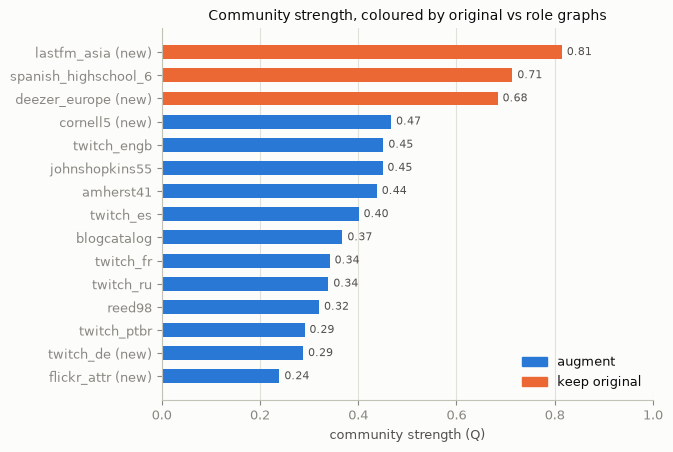

In [3]:
t = cmp[["dataset", "nodes", "edges", "orig_communities", "orig_modularity", "stage1_call", "nonhybrid_verdict",
         "official_verdict", "official_winners"]].copy()
t.insert(1, "set", t.dataset.map(lambda n: "new" if n in NEW else "pilot"))
t["nodes"], t["edges"], t["orig_communities"] = t.nodes.astype(int), t.edges.astype(int), t.orig_communities.round().astype(int)
t["official_winners"] = signals(t.official_winners)
t.columns = ["graph", "set", "nodes", "edges", "communities found", "community strength (Q)", "stage 1 says",
             "original vs role graphs", "official (7 variants)", "winning signal"]
show(t)

d = cmp.sort_values("orig_modularity")
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.barh(d.dataset.map(mark), d.orig_modularity, height=0.6, color=[VERDICT[v] for v in d.nonhybrid_verdict])
for yy, v in enumerate(d.orig_modularity):
    ax.text(v + 0.01, yy, f"{v:.2f}", va="center", fontsize=8, color=INK2)
ax.set(xlim=(0, 1), xlabel="community strength (Q)", title="Community strength, coloured by original vs role graphs")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=l) for l, c in VERDICT.items()], loc="lower right")
plt.tight_layout()
plt.show()

**The three graphs with strong communities (Q 0.68-0.81) are exactly the three where the original graph should be kept. Every other graph has Q ≤ 0.47, and augmentation helps on all of them.**

## 3 · Q1 - low homophily + low clustering = weak communities?

Colour = what stage 1 says. Grey lines = the frozen cuts (rule 1 on homophily; the clustering exception).

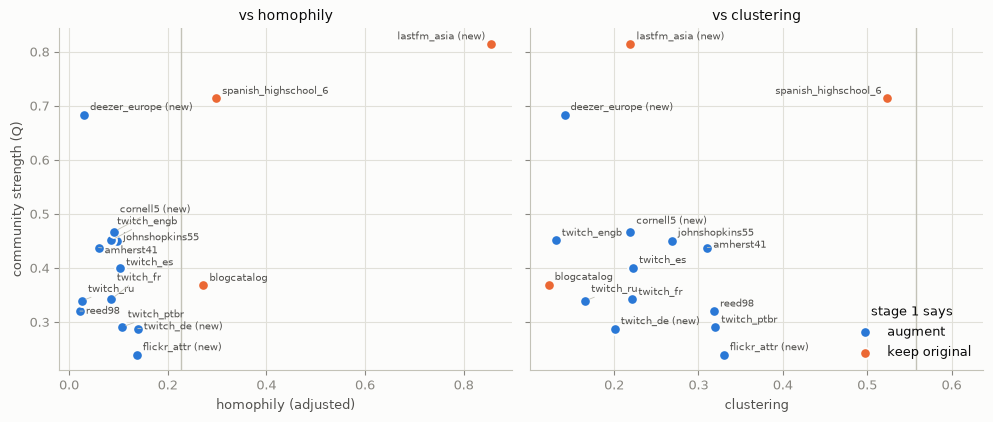

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharey=True)
dots(axes[0], cmp, "homophily_adjusted", "orig_modularity", "stage1_call")
axes[0].set(xlabel="homophily (adjusted)", ylabel="community strength (Q)", title="vs homophily")
axes[0].axvline(fr.FROZEN_RULES[0].point, color=AXIS, linewidth=1)
dots(axes[1], cmp, "avg_clustering", "orig_modularity", "stage1_call")
axes[1].set(xlabel="clustering", title="vs clustering")
axes[1].axvline(fr.FROZEN_EXCEPTION.point, color=AXIS, linewidth=1)
axes[1].set_xlim(right=max(cmp.avg_clustering.max(), fr.FROZEN_EXCEPTION.point) + 0.08)
axes[1].legend(title="stage 1 says", loc="lower right")
plt.tight_layout()
label_points(axes[0], named(cmp), "homophily_adjusted", "orig_modularity")
label_points(axes[1], named(cmp), "avg_clustering", "orig_modularity")
plt.show()

**Partly.** Low homophily usually comes with weak communities, and there augmentation helps. The exception is `deezer_europe`: low homophily, yet strong communities - and it is a keep case, which stage 1 (homophily) gets wrong and community strength gets right. Clustering tells nothing about communities, and on social graphs the clustering exception never fires (every graph sits left of its cut).

## 4 · Q2 - strong communities = keep the original?

Gain = best augmented AUC − original AUC (existing results). Above 0 = augmentation helps. Left: against the pure role graphs; right: the official verdict over all 7 variants (hybrids included).

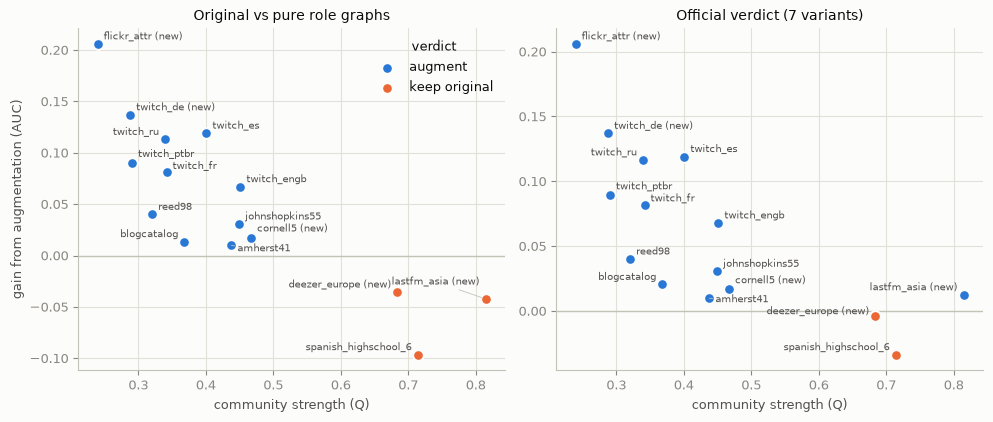

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharex=True)
dots(axes[0], cmp, "orig_modularity", "nonhybrid_gap", "nonhybrid_verdict")
axes[0].set(xlabel="community strength (Q)", ylabel="gain from augmentation (AUC)", title="Original vs pure role graphs")
dots(axes[1], cmp, "orig_modularity", "official_gap", "official_verdict")
axes[1].set(xlabel="community strength (Q)", title="Official verdict (7 variants)")
for ax in axes:
    ax.axhline(0, color=AXIS, linewidth=1)
axes[0].legend(title="verdict", loc="upper right")
plt.tight_layout()
label_points(axes[0], named(cmp), "orig_modularity", "nonhybrid_gap")
label_points(axes[1], named(cmp), "orig_modularity", "official_gap")
plt.show()

**Yes.** The weaker the communities, the more augmentation gains (ρ −0.83 over 15 graphs; −0.54 in the pilot). The three graphs that should stay as they are have the three strongest communities, with a clear gap to the rest. Both stage-1 misses are explained by community strength: `blogcatalog` (homophily says keep; weak communities, augmentation helps) and `deezer_europe` (homophily says augment; strong communities, keep). On `lastfm_asia` every pure role graph loses to the original, but a hybrid - which keeps all the original edges - gains slightly, so the official verdict counts it as augment.

_Disclosure: `lastfm_asia` and `deezer_europe` were added because they are keep cases, and their Q had been seen in an earlier run; the three unseen new graphs (`flickr_attr`, `twitch_de`, `cornell5`) all fall on the weak side and augment._

## 5 · Q3 - does centrality link important nodes across communities?

Important node = top 10% most central. Each cell = share of their edges that **cross** between communities. `original` = the real edges; `random` = what random edges would do.

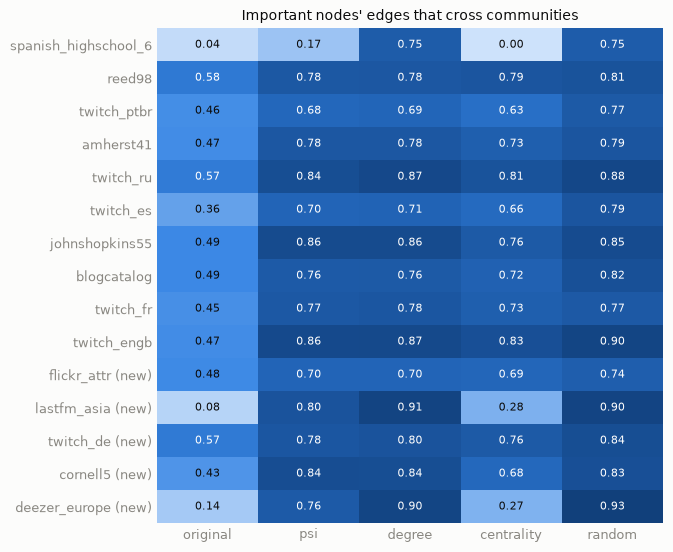

graph,centrality wins?,winning role graph,crossing: centrality,crossing: psi,crossing: degree
reed98,yes,centrality,0.79,0.78,0.78
twitch_ptbr,no,degree / psi,0.63,0.68,0.69
amherst41,yes,centrality,0.73,0.78,0.78
twitch_ru,no,degree / psi,0.81,0.84,0.87
twitch_es,no,degree / psi,0.66,0.70,0.71
johnshopkins55,yes,centrality,0.76,0.86,0.86
blogcatalog,yes,centrality / psi,0.72,0.76,0.76
twitch_fr,no,degree / psi,0.73,0.77,0.78
twitch_engb,no,degree,0.83,0.86,0.87
flickr_attr (new),yes,centrality / degree / psi,0.69,0.70,0.70


In [6]:
hub = cmp.set_index("dataset")[[f"hub_cross_{v}" for v in cfg.COMMUNITY_VARIANTS]]
hub.columns = cfg.COMMUNITY_VARIANTS
hub["random"] = summary[summary.variant == "original"].set_index("dataset").loc[hub.index, "chance_cross"]
hub.index = hub.index.map(mark)
fig, ax = plt.subplots(figsize=(6.8, 5.6))
heatmap(ax, hub, "Important nodes' edges that cross communities")
plt.tight_layout()
plt.show()

w = cmp[cmp.nonhybrid_verdict == "augment"][["dataset", "nonhybrid_winners", "hub_cross_centrality", "hub_cross_psi", "hub_cross_degree"]].copy()
w.insert(1, "centrality wins?", w.nonhybrid_winners.str.contains("centrality").map({True: "yes", False: "no"}))
w["dataset"] = w.dataset.map(mark)
w["nonhybrid_winners"] = signals(w.nonhybrid_winners)
w.columns = ["graph", "centrality wins?", "winning role graph", "crossing: centrality", "crossing: psi", "crossing: degree"]
show(w)

**No.** All three role graphs cross communities almost like random edges. Centrality's edges stay inside communities a little more than psi's and degree's (11 of 12 graphs) - but that is equally true where centrality wins (the Facebook graphs, `blogcatalog`, `flickr_attr`) and where it loses (all six Twitch graphs). Communities do not explain when centrality wins.

_Hint, not pre-registered: centrality tends to win where hubs hold fewer of the edges (Facebook graphs) and to lose where hubs dominate (Twitch). Of the three new graphs where augmentation helps it fits `cornell5` and `twitch_de`, but not `flickr_attr` (hub-dominated, yet a three-way tie that includes centrality)._

## 6 · Why - augmentation throws the communities away

How much of the original communities each role graph keeps (NMI: 0 = nothing, 1 = identical).

In [7]:
k = cmp[["dataset", "orig_modularity"] + [f"nmi_vs_original_{v}" for v in ["psi", "degree", "centrality"]]].copy()
k["dataset"] = k.dataset.map(mark)
k.columns = ["graph", "community strength (Q)", "kept by psi graph", "kept by degree graph", "kept by centrality graph"]
show(k)

graph,community strength (Q),kept by psi graph,kept by degree graph,kept by centrality graph
spanish_highschool_6,0.71,0.18,0.04,0.28
reed98,0.32,0.09,0.08,0.11
twitch_ptbr,0.29,0.05,0.04,0.06
amherst41,0.44,0.08,0.07,0.11
twitch_ru,0.34,0.04,0.03,0.05
twitch_es,0.40,0.04,0.03,0.04
johnshopkins55,0.45,0.07,0.07,0.10
blogcatalog,0.37,0.04,0.04,0.06
twitch_fr,0.34,0.02,0.02,0.03
twitch_engb,0.45,0.04,0.03,0.05


**Role graphs keep almost none of the communities (at most 0.28).** Replacing the real edges with them costs little when communities are weak - and most when they are strong. That is the mechanism behind Q2.

## 7 · What this means for the paper

- **Stage 1 gets a label-free explanation:** augment where communities are weak, keep the original where they are strong - the three keep graphs have the three strongest communities out of 15.
- Stage 1 (homophily) is right on 13 of 15 graphs; on both misses (`blogcatalog`, `deezer_europe`) community strength sides with the result.
- **Clustering adds nothing** on social graphs.
- **Stage 2 (centrality) is not explained by communities.**
- Caveat: 3 keep graphs, two of them chosen as keep cases - a strong pattern on 15 social graphs, not a validated rule.

## Appendix · statistics and checks

The seven comparisons fixed before the run (`docs/paper_log.md`), for the pilot (10 graphs, kept as it was) and the final pool (15 graphs). Spearman ρ; |ρ| ≥ 0.65 is p < 0.05 at n = 10, |ρ| ≥ 0.52 at n = 15. Descriptive only - no threshold is read from them.

In [8]:
both = pd.concat([corr10.assign(graphs="10 (pilot)"), corr.assign(graphs="15 (final)")], ignore_index=True)
show(both[["graphs"] + list(corr.columns)], digits=3)
print("role graphs rebuilt vs the study's recorded hashes:", dict(graphs.hash_status.value_counts()))
print("KNOWN_EXCEPTION = psi role graph rebuilt on Windows, last floating-point digits differ (documented psi exception)")

graphs,hypothesis,statistic,x,y,subset,n,value,p,expected,direction_holds
10 (pilot),H1,spearman,orig_modularity,homophily_adjusted,all,10,0.370,0.293,+,True
10 (pilot),H1,spearman,orig_modularity,avg_clustering,all,10,-0.030,0.934,+,False
10 (pilot),H2,spearman,orig_modularity,official_gap,all,10,-0.539,0.108,-,True
10 (pilot),H2,spearman,orig_modularity,nonhybrid_gap,all,10,-0.539,0.108,-,True
10 (pilot),H3,spearman,hub_cross_centrality,centrality_advantage,non-hybrid verdict augments,9,-0.259,0.500,+,False
10 (pilot),H2,median keep - median augment,orig_modularity,nonhybrid_verdict,all,1 keep / 9 augment,0.346,0.200,+,True
10 (pilot),H2,median keep - median augment,orig_modularity,official_verdict,all,1 keep / 9 augment,0.346,0.200,+,True
15 (final),H1,spearman,orig_modularity,homophily_adjusted,all,15,0.136,0.630,+,True
15 (final),H1,spearman,orig_modularity,avg_clustering,all,15,-0.196,0.483,+,False
15 (final),H2,spearman,orig_modularity,official_gap,all,15,-0.821,0.000,-,True


role graphs rebuilt vs the study's recorded hashes: {'NO_REFERENCE': 48, 'EXACT': 10, 'KNOWN_EXCEPTION': 2}
KNOWN_EXCEPTION = psi role graph rebuilt on Windows, last floating-point digits differ (documented psi exception)
